In [2]:
import sys  
sys.path.insert(1, '../bwm_gabriel')

from pathlib import Path
import os

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from skimage.morphology import local_maxima

from UNet_class_and_functions import *

from tqdm.auto import tqdm
tqdm.pandas()

/Users/superbg/mamba/envs/idmybee/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
PROJECT_ROOT = Path.cwd().parent
MANIFEST_DIR = PROJECT_ROOT / 'data' / 'manifests'
OUTPUT_DIR = PROJECT_ROOT / 'out'
CROP_ROOT = OUTPUT_DIR / 'crop'
PREDICT_ROOT = OUTPUT_DIR / 'predict'
MODEL_DIR = PROJECT_ROOT / 'bwm_gabriel' / 'best_model'

print(f'Racine du projet : {PROJECT_ROOT}')
print(f'Crop root : {CROP_ROOT}')

Racine du projet : /Users/superbg/Documents/Jules/IEES/idmybee
Crop root : /Users/superbg/Documents/Jules/IEES/idmybee/out/crop


In [4]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
device

device(type='cpu')

In [5]:
model_name = "UNet_150_epoch_lr=0.001_seed=58_func=pow_param=30"

model_load = torch.load(MODEL_DIR / (model_name + '.pth'),
                        weights_only=False, map_location=device)
model_load.to(device)
model_load.eval()

UNet(
  (encoder1): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (encoder2): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (encoder3): DoubleConv(
    (conv): S

In [6]:
def list_directory_contents(directory):
    """return a list of all directories and folder inside directory"""
    pictures_list = []

    try:
        with os.scandir(directory) as entries:
            for entry in entries:
                #print(entry.name)
                pictures_list.append(entry.name)
    except FileNotFoundError:
        print(f"The directory {directory} does not exist.")
    except NotADirectoryError:
        print(f"{directory} is not a directory.")
    except PermissionError:
        print(f"Permission denied to access {directory}.")
    return pictures_list

In [7]:
samples = list_directory_contents(CROP_ROOT)
samples

['FR73ABOM120722028_S3.png',
 'FR15ABOM130722047_S1.png',
 'CD388016_P2.png',
 'FR73ABOM200722031_S1.png',
 'CollecYvan4_S2.png',
 '2020.06348_P1.png',
 'FR05ABOM220722027_P1.png',
 'FR15_ABOM180720046_S3.png',
 'CollecYvan8_P2.png',
 'FR15ABOM210821112_P2.png']

In [8]:
crops = []
crops_t = []
out_crops = []
annotations = []

for name in samples:
    crop = cv2.imread(str(CROP_ROOT / name))
    crop = cv2.cvtColor(crop,cv2.COLOR_BGR2RGB)
    crops.append(crop)

    crop_t = torch.Tensor(crop.transpose(2,0,1)/255).unsqueeze(0)
    crops_t.append(crop_t)

    crop_t = crop_t.to(device)
    output = model_load(crop_t).cpu().squeeze(0).detach().numpy().transpose(1,2,0)
    out_crops.append(output)

    output = output.squeeze(axis = 2)
    maximas = np.argwhere(local_maxima(output) == True)
    scores = np.array([output[pt[0],pt[1]] for pt in maximas])
    sorter = np.argsort(scores)
    maximas = maximas[sorter,:]
    maximas = maximas[-18:,:]
    annotations.append(maximas)

In [9]:
manifest = pd.read_csv(MANIFEST_DIR / 'manifest.csv')

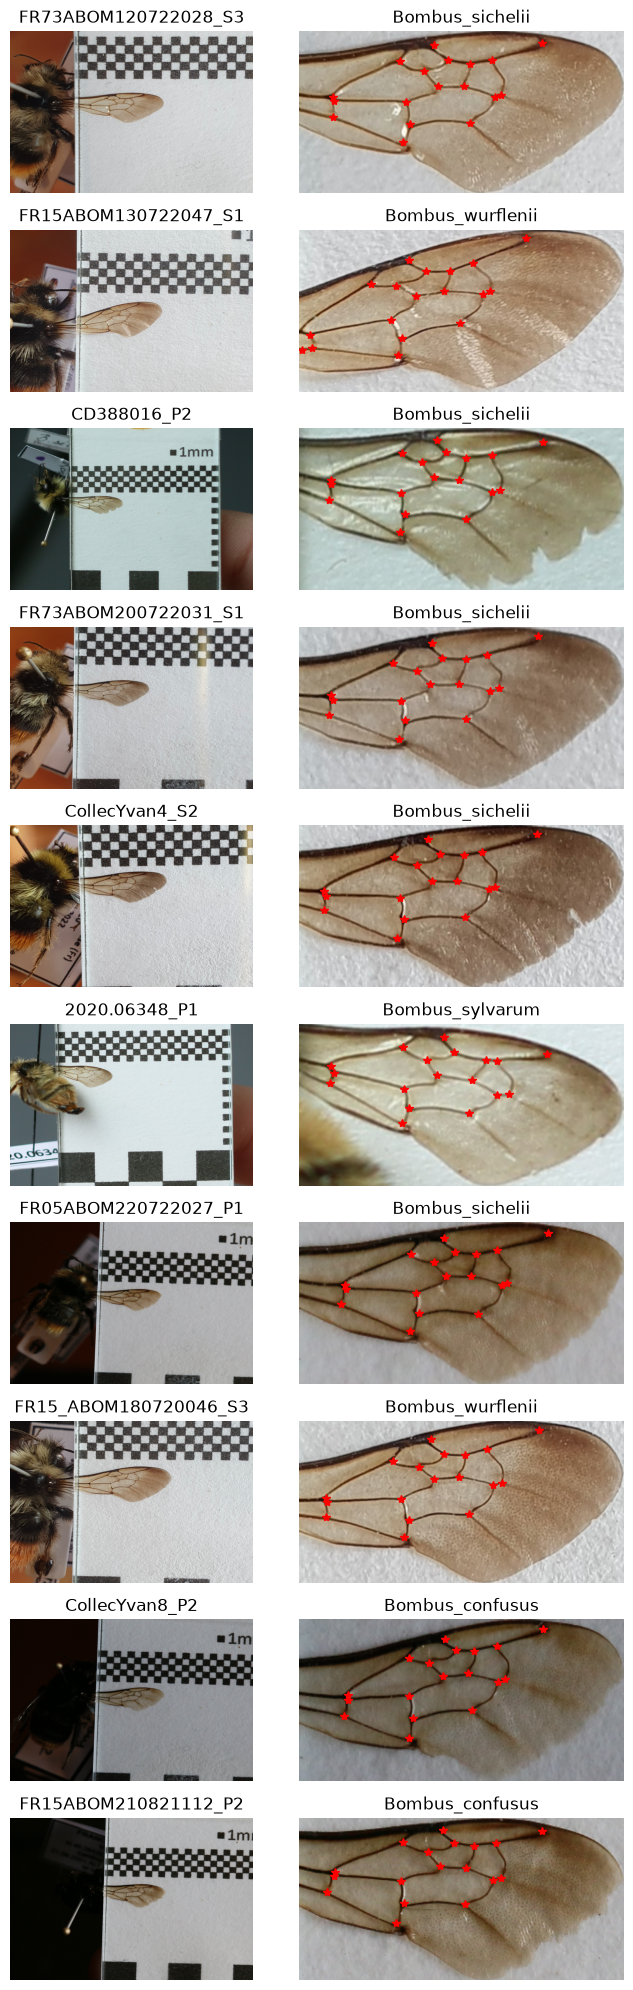

In [17]:
fig, axes = plt.subplots(len(samples), 2, figsize=(7, 2*len(samples)))
if len(samples) == 1:
    axes = axes.reshape(1, -1)

for crop, annotation, name, ax in zip(crops, annotations, samples, axes):
    im_id = Path(name).stem
    indiv = manifest.loc[manifest.id == im_id]

    base_path = PROJECT_ROOT / indiv['chemin_wide'].iloc[0]
    image = cv2.imread(str(base_path), cv2.IMREAD_COLOR)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (1440, 960))

    ax[0].imshow(image)
    ax[0].set_title(f'{im_id}')

    ax[1].imshow(crop)
    ax[1].plot(annotation[:,1],annotation[:,0],'r*')
    ax[1].set_title(f"{indiv.espece.iloc[0]}")

    ax[0].axis('off')
    ax[1].axis('off')

plt.tight_layout()
plt.savefig(PREDICT_ROOT / 'UNet_predictions.png', dpi=300)
plt.show()

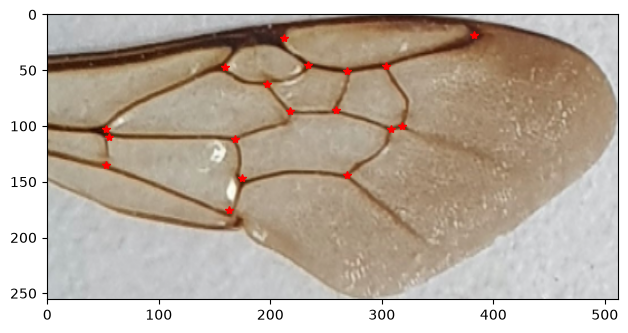

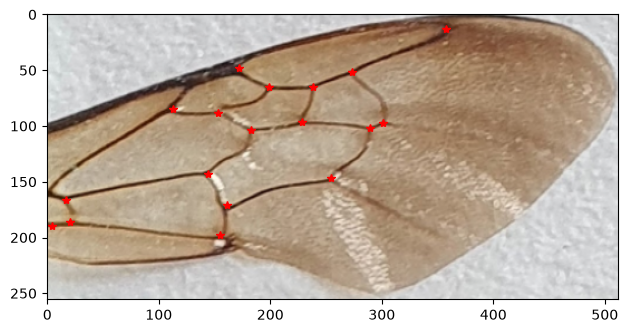

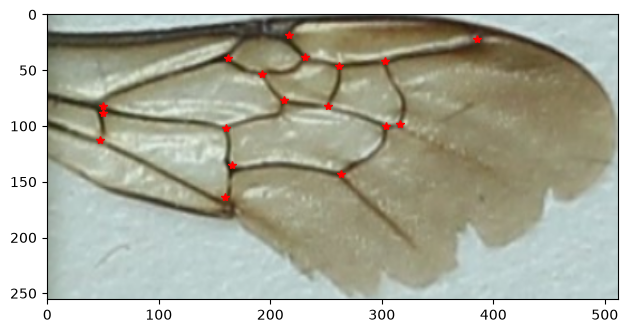

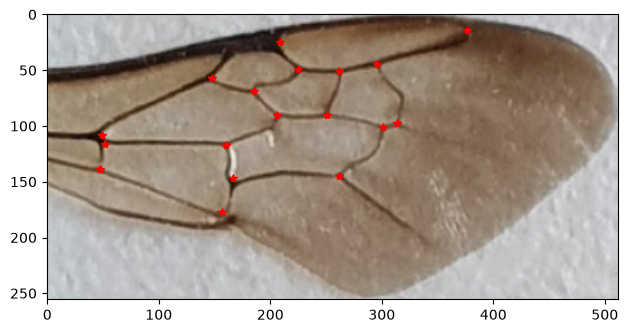

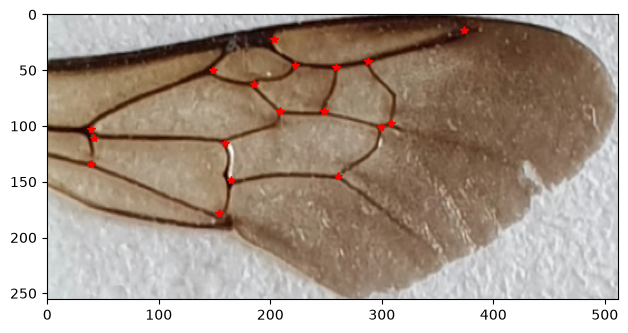

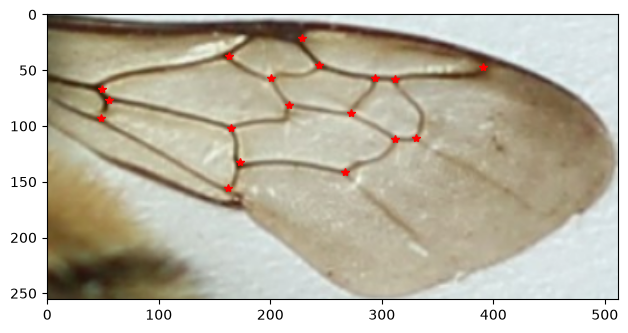

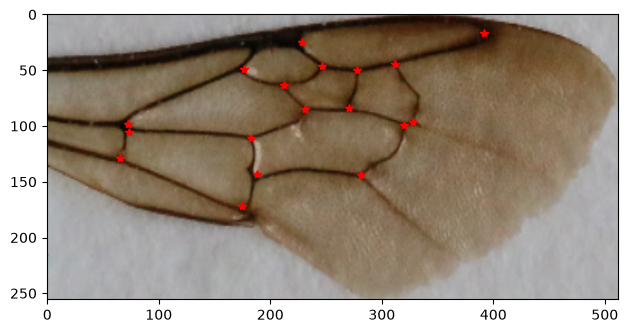

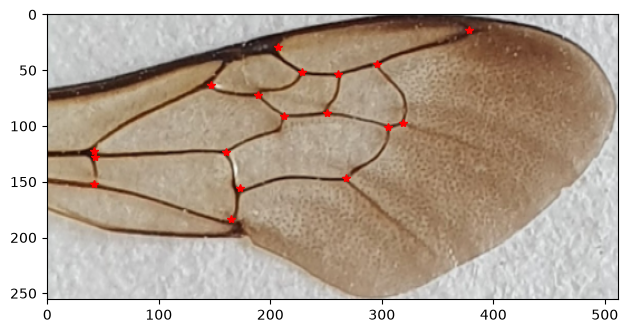

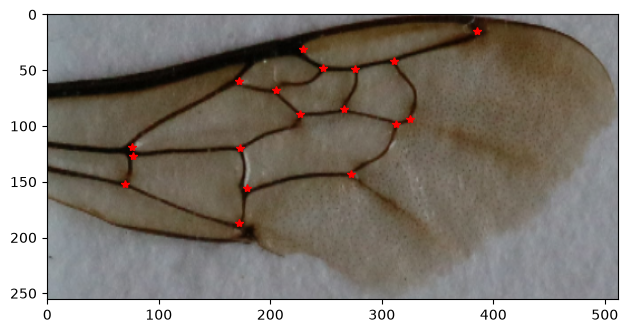

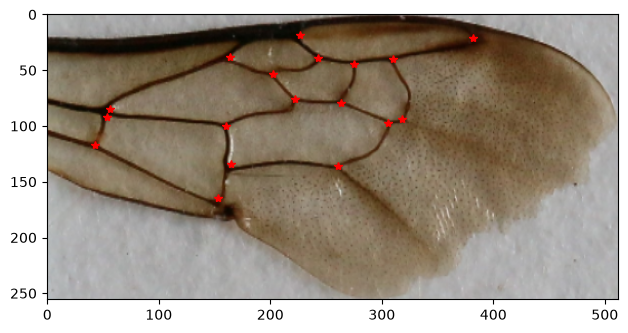

In [11]:
for crop, annotation, name in zip(crops, annotations, samples):
    plt.imshow(crop)
    plt.plot(annotation[:,1],annotation[:,0],'r*')
    plt.savefig(str(PREDICT_ROOT / f'predict_{name}'))

    plt.tight_layout()
    plt.show()